# Analysing RNTuple CAFs with Python with uproot and awkward

## Import modules etc.

In [249]:
!pip install uproot awkward matplotlib mplhep numpy


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [250]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import mplhep

In [251]:
mplhep.style.use("DUNE")
plt.rcParams["figure.figsize"] = (7, 6)

## Open CAF and have an explore

In [252]:
caf = uproot.open("../rntuple.root")["caf"].arrays()

Use `.fields` to understand what you can access. The structure should be the same as you see in the doxygen documentation for StandardRecord: https://dune.github.io/duneanaobj/classcaf_1_1StandardRecord.html

In [253]:
caf.fields

['rec']

In [254]:
caf.rec.fields

['meta', 'beam', 'mc', 'common', 'fd', 'nd']

Let's have a look at the interaction vertices

In [255]:
caf.rec.common.ixn.dlp.vtx

<Array [[{x: -196, y: -123, ...}, ...], ...] type='769 * var * {x: float32,...'>

In [256]:
caf.rec.common.ixn.dlp.vtx[0] # first spill

<Array [{x: -196, y: -123, z: 447}, ..., {...}] type='139 * {x: float32, y:...'>

In [257]:
caf.rec.common.ixn.dlp.vtx[0][0] # first interaction of first spill

<Record {x: -196, y: -123, z: 447} type='{x: float32, y: float32, z: float32}'>

Can also index like this

In [258]:
caf.rec.common.ixn.dlp.vtx[0, 0] # first interaction of first spill

<Record {x: -196, y: -123, z: 447} type='{x: float32, y: float32, z: float32}'>

or even like this if it makes more sense to you

In [259]:
caf.rec.common.ixn.dlp[0].vtx[0]  # first interaction of first spill

<Record {x: -196, y: -123, z: 447} type='{x: float32, y: float32, z: float32}'>

And now lets look at some particle properties like start and end positions

In [260]:
caf.rec.common.ixn.dlp.part.dlp.start

<Array [[[{x: -210, ...}, ...], ...], ...] type='769 * var * var * {x: floa...'>

In [261]:
caf.rec.common.ixn.dlp.part.dlp.start[0, 0, 0]

<Record {x: -210, y: -129, z: 419} type='{x: float32, y: float32, z: float32}'>

In [262]:
caf.rec.common.ixn.dlp[0].part.dlp[0].start[0]

<Record {x: -210, y: -129, z: 419} type='{x: float32, y: float32, z: float32}'>

First indexing can be a bit of a faff and we don't always need to retain the structure. In these cases, we can flatten the arrays like so

In [263]:
spills = caf.rec.common # all spills
ixns = ak.flatten(spills.ixn.dlp)

ixns[0] # first interaction

<Record {id: 0, vtx: {...}, dir: {...}, ...} type='{id: int64, vtx: {x: flo...'>

And we can go one further to flatten to all particles if we really wanted

In [264]:
parts = ak.flatten(ixns.part.dlp)
parts[0] # first particle

<Record {primary: True, pdg: 11, tgtA: 0, ...} type='{primary: bool, pdg: i...'>

Applying selections can be done like

In [265]:
tracks = parts[~np.isinf(parts.end.x)]

This particular selection *should* be based on `origRecoObjType` but in the CAFs I wrote this tutorial in, this field was not filled correctly...

We can define functions that help us calculate quantities like track length

In [266]:
def get_length(part):
  dx = part.end.x - part.start.x
  dy = part.end.y - part.start.y
  dz = part.end.z - part.start.z 
  return (dx**2 + dy**2 + dz**2)**0.5

And this can be applied to a single particle

In [267]:
get_length(tracks[0])

np.float32(34.047657)

or to all at once

In [268]:
get_length(tracks)

<Array [34, 355, 236, 111, ..., 6.45, 1.93, 1.58, 2.04] type='235998 * float32'>

And we could have done this before we flatten things if we really wanted to

In [269]:
get_length(caf.rec.common.ixn.dlp.part.dlp)

<Array [[[inf, inf, inf], ..., [3.68]], ...] type='769 * var * var * float32'>

Here we get a bunch of inf's because I did not filter to get only tracks (showers have no end). But the point is the structure. The type is 769 * var * var * float32, meaning 769 spills, which have a variable number of interactions, which have a variable number of particles, and the type of for the length is float32.

Let's move on to some concrete analysis examples.

## Plot all track lengths

In [270]:
def plot(feature, label, range=None):
  plt.hist(ak.flatten(feature, axis=None), bins=50, range=range, histtype='step') # axis=None flattens across all dimensions
  plt.xlabel(label)
  plt.ylabel("Frequency")
  plt.show()

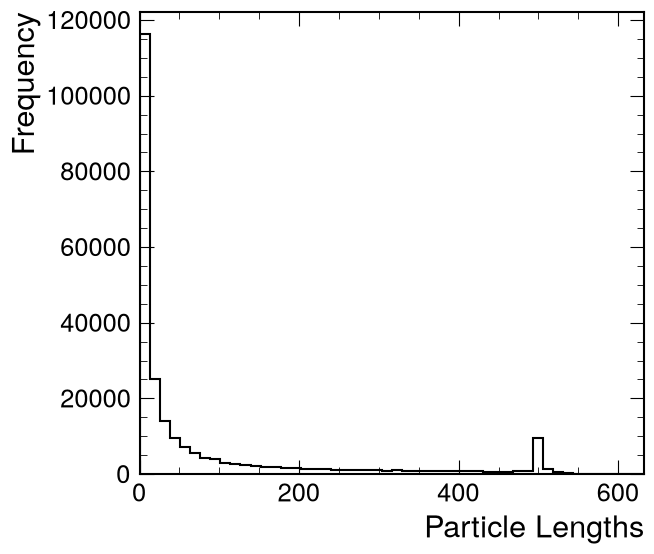

In [271]:
parts = caf.rec.common.ixn.dlp.part.dlp
tracks = parts[~np.isinf(parts.end.x)]

plot(get_length(tracks), "Particle Lengths")

### "I like my for loops"

If you really want, you can write for loops, but it will be slower!

In [ ]:
lengths = []

for spill in caf.rec.common.ixn.dlp:
  for ixn in spill:
    for part in ixn.part.dlp:
      if not np.isinf(part.start.x):
        lengths.append(get_length(part))
    
lengths

[inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 34.04765839220353,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 355.33319530758735,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 235.7006841313788,
 110.86979448039489,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 0.8318107205268066,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 396.0621202854421,
 497.52053977700257,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 463.0554097513601,
 inf,
 5.416394368687838,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 496.4907476479295,
 inf,
 inf,
 inf,
 inf,
 44.643085992717005,
 1.7047406853509337,
 15.73871704922192,
 7.641853842181469,
 1.1763966112860442,
 3.60666941512797,
 1.2886515106692003,
 1.7047006860042984,
 67.16427650963345,
 54.022015640182524,
 2.857389834492271,
 5.834614022767721,
 3.1123618344200423,
 0.0,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 1.176358052965142,
 0.9112328968091379,
 2.1691106315035342,
 2.232

## Neutrino vertex positions

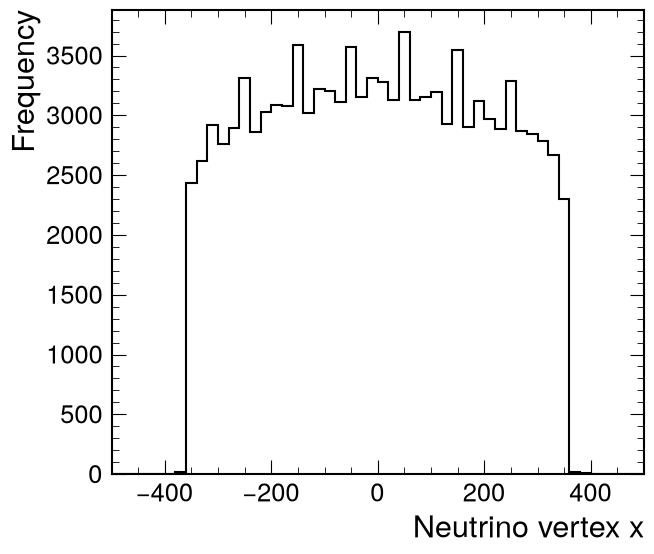

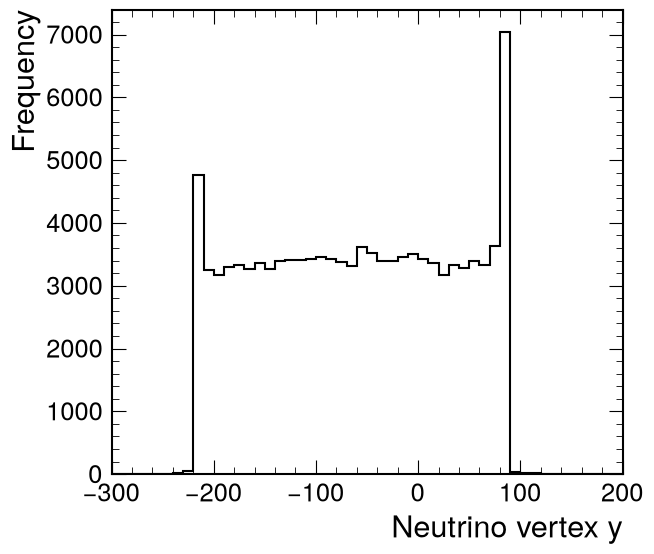

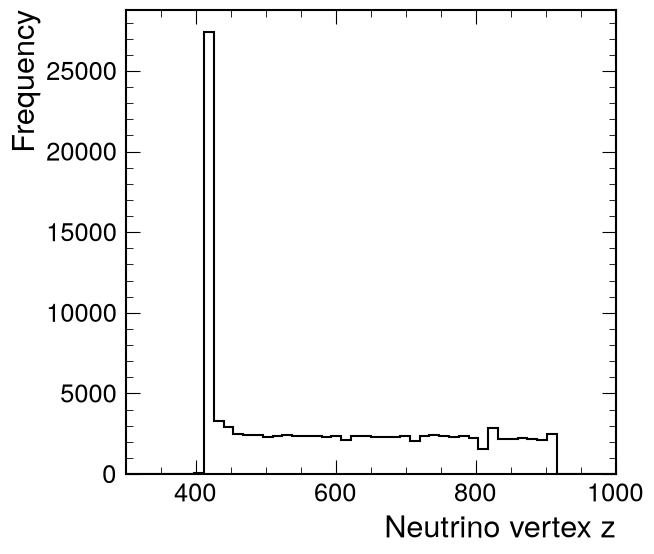

In [272]:
plot(caf.rec.common.ixn.dlp.vtx.x, "Neutrino vertex x", range=(-500, 500))
plot(caf.rec.common.ixn.dlp.vtx.y, "Neutrino vertex y", range=(-300, 200))
plot(caf.rec.common.ixn.dlp.vtx.z, "Neutrino vertex z", range=(300, 1000))

## Applying a selection and calculating an efficiency

Let's try a selection where all vertices are inside a fiducial volume, all interactions have primaries, and all primary particles are contained

In [273]:
def inFV(ixn):
  NDLArXLo = -346.9
  NDLArXHi = 346.9
  NDLArYLo = -215.5
  NDLArYHi = 81.7
  NDLArZLo = 418.2
  NDLArZHi = 913.3
  return ((NDLArXLo <= ixn.vtx.x) & (ixn.vtx.x <= NDLArXHi) &
          (NDLArYLo <= ixn.vtx.y) & (ixn.vtx.y <= NDLArYHi) &
          (NDLArZLo <= ixn.vtx.z) & (ixn.vtx.z <= NDLArZHi))
  
def passes_selection(ixn):
  has_primary = ak.any(ixn.part.dlp.primary, axis=-1)
  all_primary_contained = ak.all(ixn.part.dlp.contained | ~ixn.part.dlp.primary, axis=-1)

  return inFV(ixn) & has_primary & all_primary_contained

In [274]:
ixns = ak.flatten(caf.rec.common.ixn.dlp)

In [275]:
selection_mask = passes_selection(ixns)
efficiency = ak.mean(selection_mask) # equivalent to ak.sum(selection_mask) / len(selection_mask), which is equivalent to the fraction of events passing the selection
print("Selection efficiency:", efficiency)

Selection efficiency: 0.08389121338912134


## Muon resolution plot (truth matching)

## **WARNING: I could not complete this, need to ask questions about how truth matching is done.**

In [277]:
parts = caf.rec.common.ixn.dlp.part.dlp
muons = parts[abs(parts.pdg) == 13]

In [278]:
muons.fields

['primary',
 'pdg',
 'tgtA',
 'score',
 'E',
 'E_method',
 'p',
 'start',
 'end',
 'contained',
 'walldist',
 'origRecoObjType',
 'parent',
 'daughters',
 'truth',
 'truthOverlap',
 'recoobj']

In [279]:
muons.truth

<Array [[[], [], ..., [[{...}]], []], ...] type='769 * var * var * var * {i...'>

First lets filter by reco muons that actually have at least one match

In [280]:
ak.num(muons.truth, axis=-1)

<Array [[[], [], [3], ..., [...], [1], []], ...] type='769 * var * var * int64'>

In [281]:
has_truth_match = ak.num(muons.truth, axis=-1) > 0
truth_matched_muons = muons[has_truth_match]

Now we need to start exploring the mc branch

In [282]:
caf.rec.mc.nu[0,0].fields

['id',
 'genieIdx',
 'pdg',
 'pdgorig',
 'iscc',
 'mode',
 'targetPDG',
 'hitnuc',
 'removalE',
 'E',
 'vtx',
 'momentum',
 'isvtxcont',
 'time',
 'bjorkenX',
 'inelasticity',
 'Q2',
 'q0',
 'modq',
 'W',
 't',
 'ischarm',
 'isseaquark',
 'resnum',
 'xsec',
 'genweight',
 'baseline',
 'prod_vtx',
 'parent_dcy_mom',
 'parent_dcy_mode',
 'parent_pdg',
 'parent_dcy_E',
 'imp_weight',
 'generator',
 'genVersion',
 'nproton',
 'nneutron',
 'npip',
 'npim',
 'npi0',
 'nprim',
 'prim',
 'nprefsi',
 'prefsi',
 'nsec',
 'sec',
 'xsec_cvwgt',
 'xsec_systs',
 'flux_systs']

In [283]:
truth_matched_muons[0,3,0]

<Record {primary: True, pdg: 13, tgtA: 0, ...} type='{primary: bool, pdg: i...'>

In [284]:
caf.rec.mc.nu[0,5].prim[0]

<Record {pdg: 14, G4ID: 0, ...} type='{pdg: int32, G4ID: int32, interaction...'>

In [285]:
parts = caf.rec.common[0].ixn.dlp.part.dlp
parts

<Array [[{primary: True, ...}, ...], ...] type='139 * var * {primary: bool,...'>

In [286]:
mc = caf.rec.mc[0].nu
mc

<Array [{id: 1000025000001168, ...}, ...] type='98 * {id: int64, genieIdx: ...'>

In [287]:
parts[0,0]

<Record {primary: True, pdg: 11, tgtA: 0, ...} type='{primary: bool, pdg: i...'>

In [288]:
mc[0].sec[0]

<Record {pdg: 22, G4ID: 317, ...} type='{pdg: int32, G4ID: int32, interacti...'>